In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as tt

from sklearn.datasets import make_regression

In [2]:
data = pd.read_csv('../Data/res_demo_1.csv').sample(20)

In [3]:
data.head()

,Unnamed: 0,x,y_lin,y_fan_back
40,41,41,125.625651,255.502711
98,99,99,313.596385,400.412358
44,45,45,128.286966,212.132887
69,70,70,188.490444,245.137520
3,4,4,25.031098,29.277689


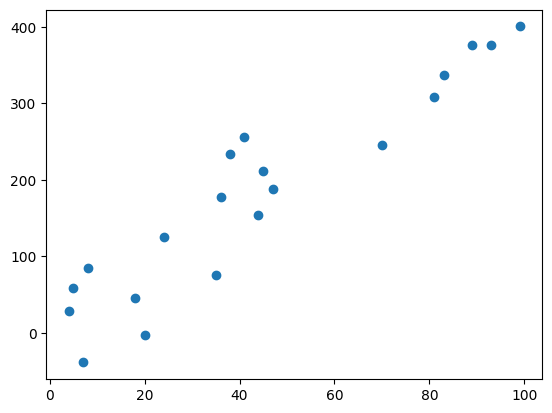

In [4]:
plt.scatter(data.x, data.y_fan_back)

In [5]:
N = data.shape[0]

with pm.Model() as simple_linear:

    intercept = pm.Normal("intercept", mu=0, sigma=1, shape=1)
    betas = pm.Normal("betas", mu=0, sigma=1, shape=1)

    regression = pm.Deterministic("regression", intercept + betas*data.x)
    y = pm.Normal("y", mu=regression, sigma=100, observed=data.y_fan_back)

In [6]:
with simple_linear:
    trace_lin = pm.sample(5000, tune=200, chains=2, target_accept=0.90, return_inferencedata=True)

    # check convergence diagnostics
    assert all(az.rhat(trace_lin) < 1.03)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [intercept, betas]


Output()

Sampling 2 chains for 200 tune and 5_000 draw iterations (400 + 10_000 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


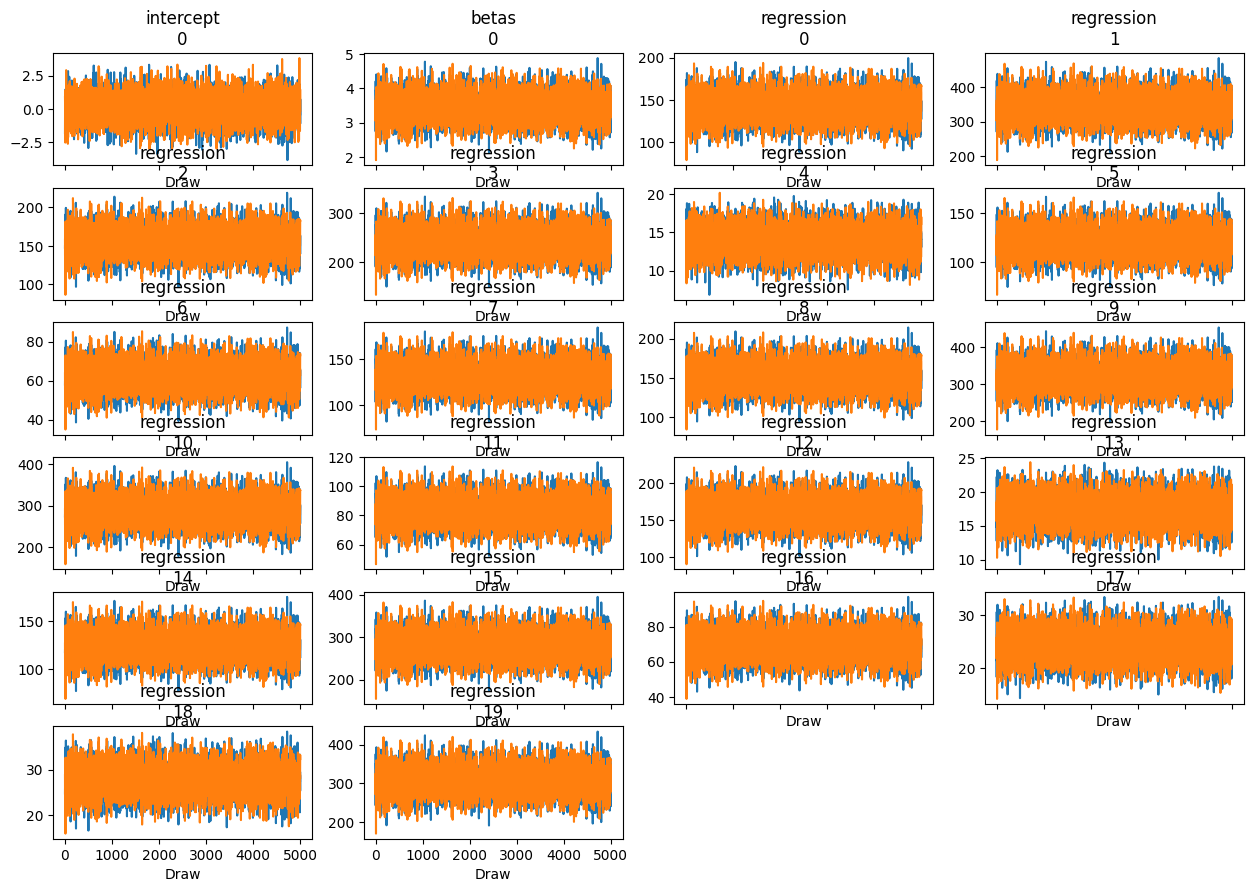

In [7]:
az.plot_trace(trace_lin, var_names=["intercept","betas","regression"])
plt.show()

<Axes: xlabel='x_'>

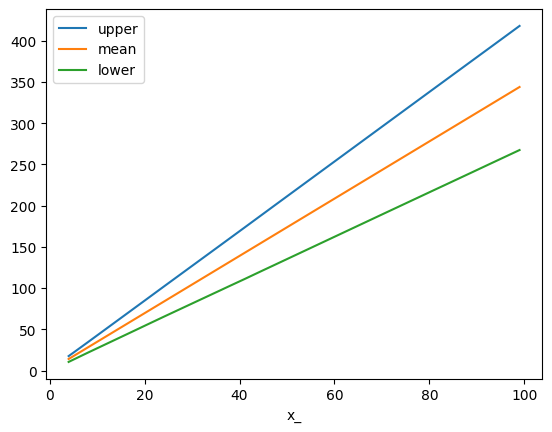

In [8]:
pd.DataFrame({
    'x_': np.tile(data.x,10000),
    'regression': trace_lin.posterior.regression.to_numpy().reshape(-1)
}).groupby('x_').regression.agg([
    ('upper',lambda x: x.quantile(0.975)),
    ('mean', lambda x: x.mean()),
    ('lower',lambda x: x.quantile(0.025))]).plot()